In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import os
import pandas as pd
import matplotlib as mpl

/home/gabriela/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/gabriela/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
os.chdir('/mnt/storage0/jmarson/ANALYSES/MASKS')

data = xr.open_dataset('ANHA4_mesh_zgr.nc')
dx = data.variables['e1t']
dy = data.variables['e2t']
e3t = data.variables['e3t_0']
lon = data.variables['nav_lon']
lat = data.variables['nav_lat'] 
bat = data.variables['hdept']
bat = bat[0]

In [3]:
os.chdir('/mnt/storage0/gabriela/ANALYSES/SCRIPTS/data_from_scripts/MixedLayerDepth')

# Divide by 198 outputs by (number of outputs per year (january to march = 18) x number of years (2007-2017 = 11 years))

vs = np.load('ANHA4-EJM010-S_AverageWinterMLD_20071_20173.npz')
vs = vs['MLD']
VS = vs/198

vd = np.load('ANHA4-EJM012-S_AverageWinterMLD_20071_20173.npz')
vd = vd['MLD']
VD = vd/198

dif_vdvs = VD - VS

In [ ]:
lon = np.array(lon)
lat = np.array(lat)
VS = np.array(VS)
VD = np.array(VD)
dif_vdvs = np.array(dif_vdvs)
dif_sdss = np.array(dif_sdss)

In [5]:
#Slicing the data to cover only the Labrador Sea

xlim1 = 150
xlim2 = 250
ylim1 = 300
ylim2 = 450

VS = VS[ylim1:ylim2, xlim1:xlim2]
VD = VD[ylim1:ylim2, xlim1:xlim2]

dif_vdvs = dif_vdvs[ylim1:ylim2, xlim1:xlim2]

lon = lon[ylim1:ylim2, xlim1:xlim2]
lat = lat[ylim1:ylim2, xlim1:xlim2]

In [8]:
print("VS shape:", VS.shape)
print("VD shape:", VD.shape)
print("dif_vdvs shape:", dif_vdvs.shape)
print("dif_sdss shape:", dif_sdss.shape)
print("lon shape:", lon.shape)
print("lat shape:", lat.shape)


VS shape: (150, 100)
VD shape: (150, 100)
dif_vdvs shape: (150, 100)
dif_sdss shape: (150, 100)
lon shape: (150, 100)
lat shape: (150, 100)


/tmp/ipykernel_79362/3106452707.py:40: UserWarning: No contour levels were found within the data range.
  ct = m.contour(lon, lat,


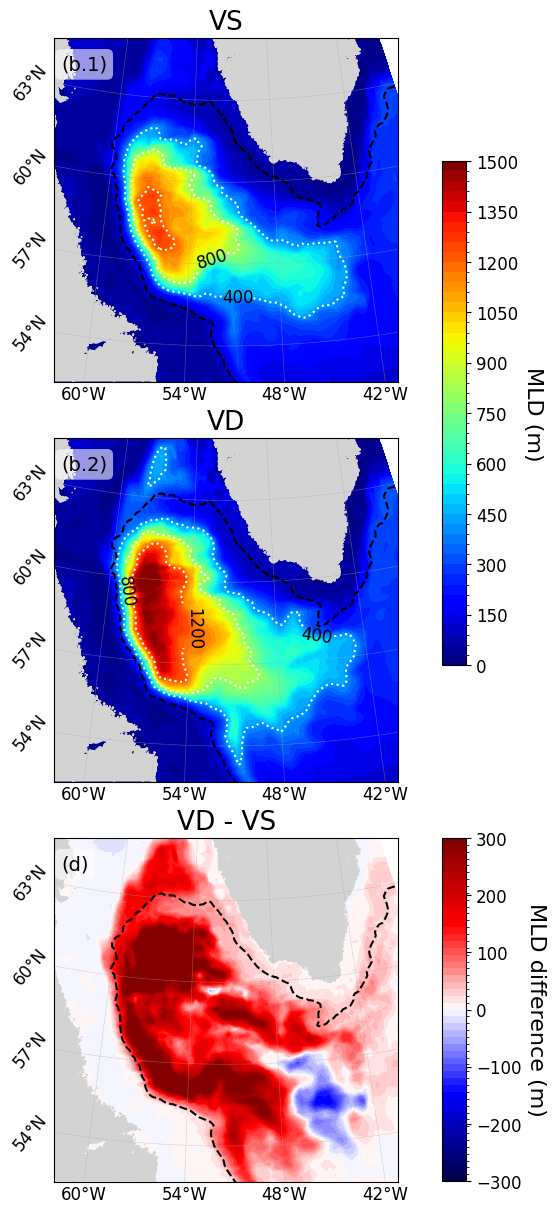

In [30]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6,12), constrained_layout=True)


vmins = [0, 0, -300]
vmaxs = [1500, 1500, 300]
lvs = 50
lv_data = (vmaxs[0] - vmins[0])/lvs
levels_data = list(np.arange(vmins[0], vmaxs[0]+lv_data, lv_data))
lv_dif = (vmaxs[2] - vmins[2])/lvs
levels_dif = list(np.arange(vmins[2], vmaxs[2]+lv_dif, lv_dif))

levels = [levels_data, levels_data, levels_dif]

cmaps = [plt.get_cmap('jet'), plt.get_cmap('jet'), plt.get_cmap('seismic')]

data_list = [VS, VD, dif_vdvs]

titles = ['VS', 'VD', 'VD - VS']

VD = np.clip(VD, 0, 1500)
VS = np.clip(VS, 0, 1500)
dif_vdvs = np.clip(dif_vdvs, -300, 300)


for ax, data, title, vmin, vmax, levels, cmap in zip(axes.flat, data_list, titles, vmins, vmaxs, levels, cmaps):
    ax.set_title(title, fontsize=19)
    m = Basemap(projection='aea', resolution='f', width=14E5, height=14E5, lat_0=59, lon_0=-51.5, ax=ax)
    m.contourf(lon, lat, data, 
               latlon=True, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap)
    
    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0,360,6), labels=[0, 0, 0, 1], linewidth=0.4, color='darkgray', fontsize=12)
    m.drawparallels(np.arange(-90,90,3), labels=[1, 0, 0, 0], linewidth=0.4, color='darkgray', fontsize=12, rotation=50)
    
    bath_contour = m.contour(lon, lat, 
                             bat, latlon=True, levels=[2000], 
                             colors='black', linewidths=1.5, linestyles='dashed')
    
    ct = m.contour(lon, lat, 
                             data, latlon=True, levels=[400, 800, 1200], 
                             colors='white', linewidths=1.5, linestyles='dotted')
    plt.clabel(ct, colors='black', fontsize=12)
    
    
# Colorbar
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
cax1 = fig.add_axes([0.86, 0.45, 0.040, 0.42])
lv = np.linspace(vmins[0], vmaxs[0], len(levels))
norm = BoundaryNorm(lv, ncolors=cmaps[0].N, clip=True)  # Use cmap.N to get the number of colors
cb1 = mpl.colorbar.ColorbarBase(cax1, cmap=cmaps[0], norm=norm, orientation='vertical')
cb1.ax.set_ylabel('MLD (m)', rotation=270, labelpad=18, fontsize = 16)
cb1.ax.ticklabel_format(style='sci', scilimits=(-1,4), axis='both')
cb1.set_ticks(np.arange(0, 1600, 150)) 
cb1.ax.tick_params(labelsize=12)  # or any size you want


cax2 = fig.add_axes([0.86, 0.02, 0.040, 0.286])
lv = np.linspace(vmin, vmax, len(levels))
norm = BoundaryNorm(lv, ncolors=cmap.N, clip=True)  # Use cmap.N to get the number of colors
cb2 = mpl.colorbar.ColorbarBase(cax2, cmap=cmap, norm=norm, orientation='vertical')
cb2.ax.set_ylabel('MLD difference (m)', rotation=270, labelpad=18, fontsize = 16)
#cb2.ax.ticklabel_format(style='sci', scilimits=(-0,4), axis='both')
cb2.set_ticks(np.arange(-300, 400, 100)) 
cb2.ax.tick_params(labelsize=12)  # or any size you want

labels = ['b.1', 'b.2', 'd']

for i, ax in enumerate(axes):
    color = 'black'
    ax.text(0.02, 0.95, f'({labels[i]})', transform=ax.transAxes,
            fontsize=14, va='top', ha='left', color=color, 
           bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.6))


figure_title = 'LabradorSeaMLD_MLDdifferences'
os.chdir('/mnt/storage0/gabriela/ANALYSES/FIGS/figs_paper')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()

plt.show()